# Fuga Temporal y Contaminación Entrenamiento-Prueba

## 1. ¿Qué es la Fuga de Datos?

**La fuga de datos** ocurre cuando información que no estaría disponible en el momento de la predicción se utiliza durante el entrenamiento. Esto infla artificialmente las métricas de rendimiento del modelo, llevando a modelos que funcionan bien en los conjuntos de prueba pero mal con datos nuevos.

### Tipos Comunes de Fuga de Datos

| Tipo | Descripción | Ejemplo |
|------|-------------|---------|
| **Fuga del objetivo** | Las características contienen información derivada del objetivo | Incluir "préstamo_aprobado" al predecir "incumplirá_pago" |
| **Contaminación entrenamiento-prueba** | La información del conjunto de prueba se filtra al entrenamiento | Ajustar un escalador en todos los datos antes de dividir |
| **Fuga temporal** | Se usa información futura para predecir el pasado | Entrenar con datos de 2015 para predecir precios de 2014 |

La fuga temporal es particularmente insidiosa porque a menudo pasa desapercibida — el modelo genuinamente aprende patrones, pero esos patrones incluyen "conocer el futuro".

## 2. Fuga Temporal Explicada

### 2.1 El Problema con las Divisiones Aleatorias
Considera un conjunto de datos de precios de viviendas con ventas desde enero de 2014 hasta mayo de 2015. Una división aleatoria 80/20 podría producir:

```
Conjunto de entrenamiento: Mezcla aleatoria de fechas de enero 2014 a mayo 2015
Conjunto de prueba:        Mezcla aleatoria de fechas de enero 2014 a mayo 2015
```

**El problema**: El modelo puede aprender de las ventas de mayo de 2015 (en entrenamiento) para predecir los precios de enero de 2014 (en prueba). Esto es **usar el futuro para predecir el pasado**.

### 2.2 Por Qué Esto No es Realista
En producción, cuando despliegas un modelo:
- Entrenas con **todos los datos históricos disponibles** (el pasado)
- Predices sobre **datos nuevos entrantes** (el futuro)

Nunca puedes usar datos futuros para entrenar un modelo que predice el pasado. Una división aleatoria viola esta restricción fundamental.

### 2.3 Lo Que Aprende el Modelo
Con fuga temporal, el modelo puede aprender:
- **Tendencias del mercado**: "Los precios en 2015 son 5% más altos que en 2014" (pero esta tendencia no continuará para siempre)
- **Patrones estacionales invertidos**: Aprender los patrones del invierno de 2015 para predecir el verano de 2014
- **Conocimiento de eventos específicos**: Eventos económicos posteriores a la fecha de predicción

## 3. Demostración con los Datos de King County

In [ ]:
import numpy as npimport pandas as pdimport matplotlib.pyplot as pltfrom sklearn.model_selection import train_test_splitfrom sklearn.ensemble import RandomForestRegressorfrom sklearn.metrics import root_mean_squared_error

In [ ]:
import kagglehubfrom pathlib import Pathpath = kagglehub.dataset_download("harlfoxem/housesalesprediction")csv_path = Path(path) / "kc_house_data.csv"df = pd.read_csv(csv_path)print(f"Dataset shape: {df.shape}")

Dataset shape: (21613, 21)


In [ ]:
# Parse dates and examine the time rangedf["date_parsed"] = pd.to_datetime(df["date"].str[:8], format="%Y%m%d")# ADD TEMPORAL característica# Use the absolute minimum date as a reference pointreference_date = df["date_parsed"].min()df["days_since_start"] = (df["date_parsed"] - reference_date).dt.daysprint(f"Date range: {df['date_parsed'].min().date()} to {df['date_parsed'].max().date()}")print(f"Duration: {(df['date_parsed'].max() - df['date_parsed'].min()).days} days")

Date range: 2014-05-02 to 2015-05-27
Duration: 390 days


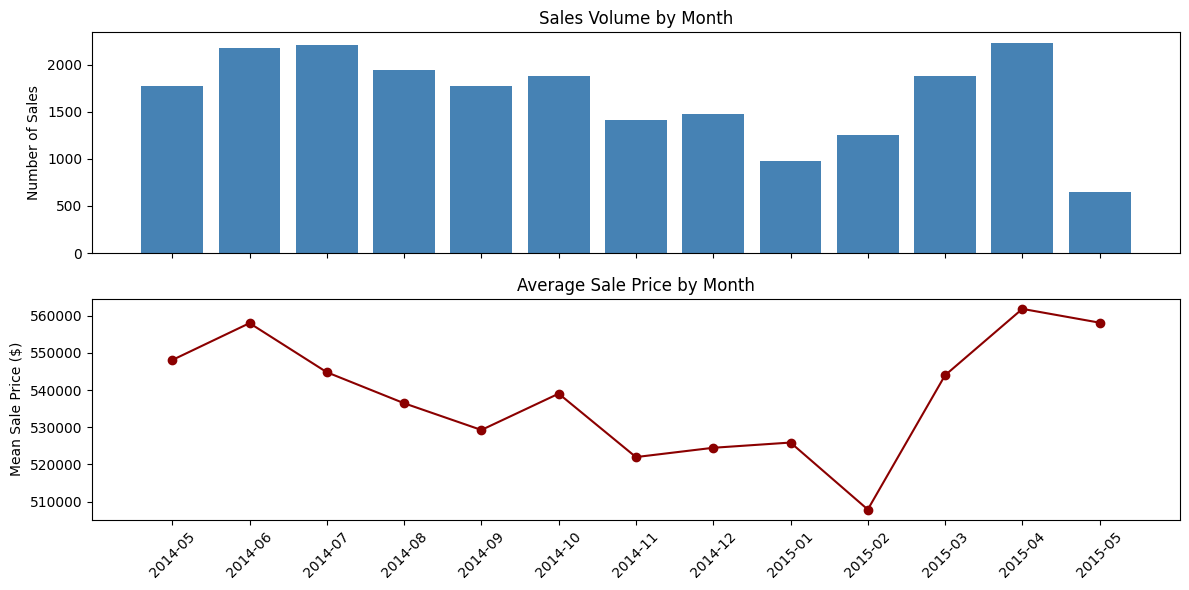

In [ ]:
# Visualize the temporal distribución of salesdf["year_month"] = df["date_parsed"].dt.to_period("M")monthly_sales = df.groupby("year_month").agg(    count=("price", "count"),    mean_price=("price", "mean")).reset_index()monthly_sales["year_month"] = monthly_sales["year_month"].astype(str)fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)axes[0].bar(monthly_sales["year_month"], monthly_sales["count"], color="steelblue")axes[0].set_ylabel("Number of Sales")axes[0].set_title("Sales Volume by Month")axes[1].plot(monthly_sales["year_month"], monthly_sales["mean_price"],              marker="o", color="darkred")axes[1].set_ylabel("Mean Sale Price ($)")axes[1].set_title("Average Sale Price by Month")axes[1].tick_params(axis='x', rotation=45)plt.tight_layout()plt.show()

**Observación**: Existe un patrón temporal claro — los precios varían a lo largo del tiempo. Un modelo entrenado en meses "futuros" tendría una ventaja injusta al predecir meses "pasados".

### 3.1 Visualizando el Problema de Fuga

In [ ]:
# Demonstrate the difference between random and temporal splitsnp.random.seed(42)# Random splittrain_random, test_random = train_test_split(df, test_size=0.2, random_state=42)# Temporal splitdf_sorted = df.sort_values("date_parsed")split_idx = int(len(df_sorted) * 0.8)train_temporal = df_sorted.iloc[:split_idx]test_temporal = df_sorted.iloc[split_idx:]print("RANDOM SPLIT:")print(f"  Train dates: {train_random['date_parsed'].min().date()} to {train_random['date_parsed'].max().date()}")print(f"  Test dates:  {test_random['date_parsed'].min().date()} to {test_random['date_parsed'].max().date()}")print(f"  ⚠️  OVERLAP: Test set contains dates from the ENTIRE range!")print("\nTEMPORAL SPLIT:")print(f"  Train dates: {train_temporal['date_parsed'].min().date()} to {train_temporal['date_parsed'].max().date()}")print(f"  Test dates:  {test_temporal['date_parsed'].min().date()} to {test_temporal['date_parsed'].max().date()}")print(f"  ✓ NO OVERLAP: Test set contains only FUTURE dates.")

RANDOM SPLIT:
  Train dates: 2014-05-02 to 2015-05-24
  Test dates:  2014-05-02 to 2015-05-27
  ⚠️  OVERLAP: Test set contains dates from the ENTIRE range!

TEMPORAL SPLIT:
  Train dates: 2014-05-02 to 2015-03-10
  Test dates:  2015-03-10 to 2015-05-27
  ✓ NO OVERLAP: Test set contains only FUTURE dates.


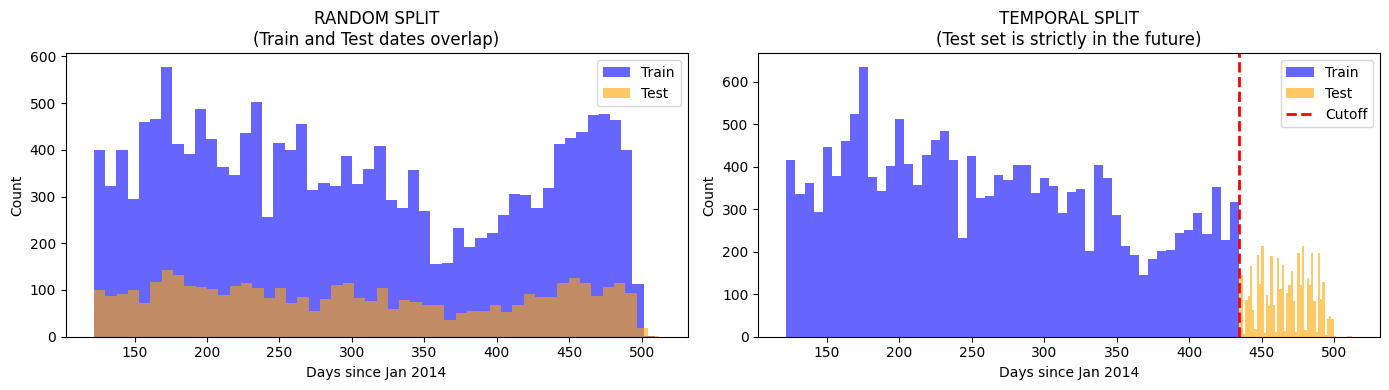

In [ ]:
# Visualize the splitsfig, axes = plt.subplots(1, 2, figsize=(14, 4))# Random splitaxes[0].hist(train_random["date_parsed"].dt.dayofyear +              (train_random["date_parsed"].dt.year - 2014) * 365,             bins=50, alpha=0.6, label="Train", color="blue")axes[0].hist(test_random["date_parsed"].dt.dayofyear +              (test_random["date_parsed"].dt.year - 2014) * 365,             bins=50, alpha=0.6, label="Test", color="orange")axes[0].set_xlabel("Days since Jan 2014")axes[0].set_ylabel("Count")axes[0].set_title("RANDOM SPLIT\n(Train and Test dates overlap)")axes[0].legend()# Temporal splitaxes[1].hist(train_temporal["date_parsed"].dt.dayofyear +              (train_temporal["date_parsed"].dt.year - 2014) * 365,             bins=50, alpha=0.6, label="Train", color="blue")axes[1].hist(test_temporal["date_parsed"].dt.dayofyear +              (test_temporal["date_parsed"].dt.year - 2014) * 365,             bins=50, alpha=0.6, label="Test", color="orange")axes[1].axvline(x=train_temporal["date_parsed"].max().dayofyear +                 (train_temporal["date_parsed"].max().year - 2014) * 365,                color="red", linestyle="--", linewidth=2, label="Cutoff")axes[1].set_xlabel("Days since Jan 2014")axes[1].set_ylabel("Count")axes[1].set_title("TEMPORAL SPLIT\n(Test set is strictly in the future)")axes[1].legend()plt.tight_layout()plt.show()

### 3.2 Cuantificando el Impacto de la Fuga Temporal

In [ ]:
# Prepare características (simple subset for demonstration)feature_cols = ["sqft_living", "bedrooms", "bathrooms", "floors",                 "waterfront", "view", "condition", "grade",                "sqft_above", "sqft_basement", "yr_built", "lat", "long", "days_since_start"]def train_and_evaluate(train_df, test_df, feature_cols, random_state=42):    """Train a RandomForest and return RMSE."""    X_train = train_df[feature_cols]    y_train = train_df["price"]    X_test  = test_df[feature_cols]    y_test  = test_df["price"]    model = RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=-1)    model.fit(X_train, y_train)    y_pred = model.predict(X_test)    return root_mean_squared_error(y_test, y_pred)# --- Temporal split (fixed, no randomness) ---rmse_temporal = train_and_evaluate(train_temporal, test_temporal, feature_cols)# --- Random split: repeat over 100 different seeds ---N_SEEDS = 50rmses_random = []for seed in range(N_SEEDS):    train_r, test_r = train_test_split(df, test_size=0.2, random_state=seed)    rmses_random.append(train_and_evaluate(train_r, test_r, feature_cols, random_state=seed))rmse_random_mean = np.mean(rmses_random)rmse_random_std  = np.std(rmses_random)pct_random_better = np.mean(np.array(rmses_random) < rmse_temporal) * 100print("Model Performance Comparison:")print(f"  Temporal split RMSE (fixed):          ${rmse_temporal:,.0f}")print(f"  Random split RMSE  (mean ± std):      ${rmse_random_mean:,.0f} ± ${rmse_random_std:,.0f}")print(f"  Random split better than temporal in: {pct_random_better:.0f}% of the {N_SEEDS} seeds")

Model Performance Comparison:
  Temporal split RMSE (fixed):          $141,937
  Random split RMSE  (mean ± std):      $132,630 ± $8,200
  Random split better than temporal in: 86% of the 50 seeds


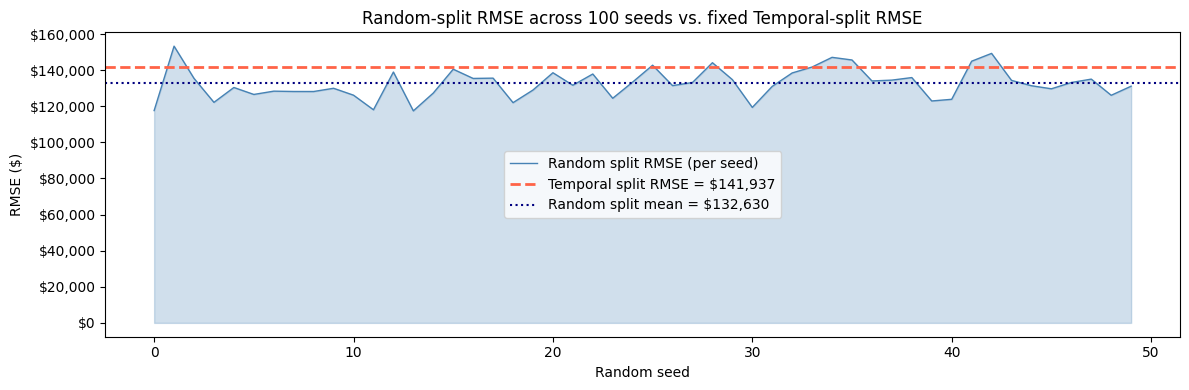

In [ ]:
import matplotlib.pyplot as pltfig, ax = plt.subplots(figsize=(12, 4))# One bar / point per seedax.plot(range(N_SEEDS), rmses_random, color="steelblue", linewidth=1, label="Random split RMSE (per seed)")ax.fill_between(range(N_SEEDS), rmses_random, alpha=0.25, color="steelblue")# Constant reference line for the temporal splitax.axhline(rmse_temporal, color="tomato", linewidth=2, linestyle="--",           label=f"Temporal split RMSE = ${rmse_temporal:,.0f}")# media of random splitsax.axhline(rmse_random_mean, color="navy", linewidth=1.5, linestyle=":",           label=f"Random split mean = ${rmse_random_mean:,.0f}")ax.set_xlabel("Random seed")ax.set_ylabel("RMSE ($)")ax.set_title("Random-split RMSE across 100 seeds vs. fixed Temporal-split RMSE")ax.legend()ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))plt.tight_layout()plt.show()

### Observaciones sobre los Resultados
El experimento con múltiples semillas revela el **sesgo sistemático** introducido por las divisiones aleatorias:

* **El RMSE con división aleatoria es menor que el RMSE con división temporal en la gran mayoría de semillas.**
   Una sola semilla es solo una muestra de una gran distribución de posibles particiones entrenamiento/prueba — puede ir en cualquier dirección por azar.
   Promediar sobre muchas semillas expone el patrón subyacente claramente.

* **¿Por qué la división aleatoria parece mejor en promedio?**
   Una división aleatoria dispersa datos de *todos* los períodos temporales en ambos conjuntos de entrenamiento y prueba.
   El modelo se entrena entonces con datos del *futuro* de muchos ejemplos de prueba — fuga temporal.
   Aprende señales de tendencia y estacionalidad que nunca tendría en producción,
   produciendo una estimación de error **artificialmente optimista**.

* **El Principio**: Una división aleatoria es fundamentalmente defectuosa para datos temporales porque permite
   al modelo "hacer trampa" (p. ej., predecir el precio de una casa de enero usando ejemplos de entrenamiento de diciembre).
   En producción, solo puedes usar el pasado para predecir el futuro — una división aleatoria viola esta
   restricción y da una falsa sensación de seguridad que a menudo lleva a un mal rendimiento en el mundo real.

## 4. El Enfoque Correcto: División Temporal

### 4.1 División Temporal Básica
El enfoque más simple: ordenar por fecha, tomar el primer 80% para entrenamiento y el último 20% para prueba.

```python
df_sorted = df.sort_values('date')
split_idx = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split_idx]
test = df_sorted.iloc[split_idx:]
```

### 4.2 Validación Cruzada Temporal
Para una evaluación más robusta, usa **TimeSeriesSplit** de scikit-learn:

```python
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(X):
    # Cada fold usa datos anteriores para entrenamiento, datos posteriores para validación
```

Esto crea ventanas de entrenamiento en expansión y ventanas de validación deslizantes.

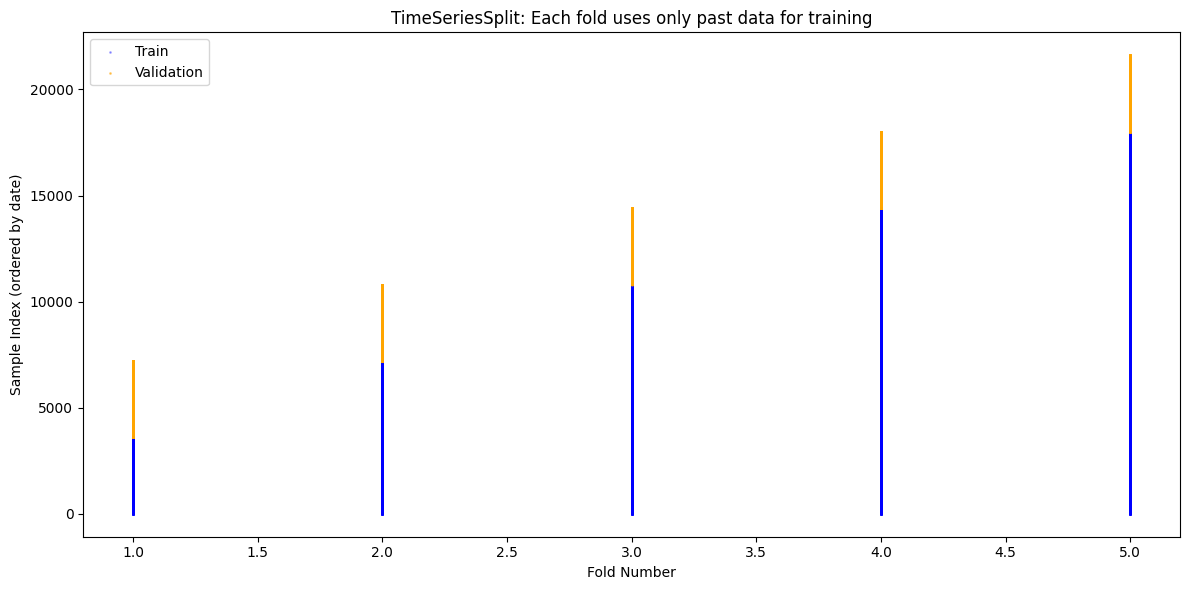

Note: In each fold, training data (blue) always comes BEFORE validation data (orange).


In [ ]:
from sklearn.model_selection import TimeSeriesSplit# Visualize TimeSeriesSplit foldsdf_sorted = df.sort_values("date_parsed").reset_index(drop=True)tscv = TimeSeriesSplit(n_splits=5)fig, ax = plt.subplots(figsize=(12, 6))for i, (train_idx, val_idx) in enumerate(tscv.split(df_sorted)):    ax.scatter([i+1] * len(train_idx), train_idx, c='blue', alpha=0.3, s=1, label='Train' if i == 0 else '')    ax.scatter([i+1] * len(val_idx), val_idx, c='orange', alpha=0.5, s=1, label='Validation' if i == 0 else '')ax.set_xlabel('Fold Number')ax.set_ylabel('Sample Index (ordered by date)')ax.set_title('TimeSeriesSplit: Each fold uses only past data for training')ax.legend()plt.tight_layout()plt.show()print("Note: In each fold, training data (blue) always comes BEFORE validation data (orange).")

## 5. Selección de Modelo Sin Fuga
Al comparar múltiples modelos, también debemos evitar la **fuga en la selección del modelo**:

### El Problema
Si usamos el mismo conjunto de prueba para:
1. Comparar diferentes modelos
2. Seleccionar el mejor modelo
3. Reportar el rendimiento final

...entonces hemos optimizado implícitamente para ese conjunto de prueba, y nuestro rendimiento reportado es excesivamente optimista.

### La Solución: División en Tres Partes
```
Datos (ordenados por tiempo)
├── Conjunto de entrenamiento (el más antiguo) ────────► Ajustar modelos
├── Conjunto de validación (intermedio) ──────► Comparar modelos, ajustar hiperparámetros
└── Conjunto de prueba (el más reciente) ────────────► Evaluación final (usado UNA VEZ)
```

El conjunto de prueba solo debe tocarse **al final**, para obtener una estimación imparcial del rendimiento en producción.

In [ ]:
def temporal_train_val_test_split(df, val_size=0.15, test_size=0.15):    """    Split data temporally into train, validation, and test sets.        Parameters    ----------    df : pd.DataFrame        Dataset with a 'date' or 'date_parsed' column.    val_size : float        Proportion for validation set.    test_size : float        Proportion for test set.            Returns    -------    tuple: (train_df, val_df, test_df)    """    date_col = "date_parsed" if "date_parsed" in df.columns else "date"    df_sorted = df.sort_values(date_col)        n = len(df_sorted)    train_end = int(n * (1 - val_size - test_size))    val_end = int(n * (1 - test_size))        train_df = df_sorted.iloc[:train_end]    val_df = df_sorted.iloc[train_end:val_end]    test_df = df_sorted.iloc[val_end:]        return train_df, val_df, test_df# aplicar to our datostrain, val, test = temporal_train_val_test_split(df, val_size=0.15, test_size=0.15)print("Temporal Three-Way Split:")print(f"  Train:      {len(train):,} records ({100*len(train)/len(df):.0f}%)")print(f"              {train['date_parsed'].min().date()} to {train['date_parsed'].max().date()}")print(f"  Validation: {len(val):,} records ({100*len(val)/len(df):.0f}%)")print(f"              {val['date_parsed'].min().date()} to {val['date_parsed'].max().date()}")print(f"  Test:       {len(test):,} records ({100*len(test)/len(df):.0f}%)")print(f"              {test['date_parsed'].min().date()} to {test['date_parsed'].max().date()}")

Temporal Three-Way Split:
  Train:      15,129 records (70%)
              2014-05-02 to 2015-01-16
  Validation: 3,242 records (15%)
              2015-01-16 to 2015-03-26
  Test:       3,242 records (15%)
              2015-03-26 to 2015-05-27


## 6. ¿Cuándo NO Es Necesaria la División Temporal?
Las divisiones temporales son esenciales cuando:
- **El tiempo es un factor**: Los precios, tendencias o patrones cambian a lo largo del tiempo
- **El uso en producción es hacia adelante**: Entrenas con datos históricos y predices observaciones futuras

Las divisiones aleatorias pueden ser aceptables cuando:
- **Los datos son i.i.d.**: Las observaciones son verdaderamente independientes e idénticamente distribuidas
- **No hay patrones temporales**: El objetivo no depende de cuándo ocurrió la observación
- **Predicción de corte transversal**: Predices entre entidades en un momento fijo

**Para datos de bienes raíces**, las divisiones temporales son casi siempre apropiadas porque:
- Los mercados evolucionan con el tiempo
- Las condiciones económicas afectan los precios
- Existen patrones estacionales
- El objetivo es predecir precios de venta futuros

## 7. Resumen

### Conceptos Clave

| Concepto | Definición |
|---------|------------|
| **Fuga temporal** | Usar información futura para entrenar un modelo que predice el pasado |
| **División temporal** | Dividir datos cronológicamente — entrenar con el pasado, probar con el futuro |
| **Fuga en selección de modelo** | Optimizar la elección del modelo usando el conjunto de prueba |
| **División en tres partes** | Entrenamiento + validación (para selección de modelo) + prueba (para evaluación final) |

### Mejores Prácticas
1. **Examina siempre los rangos de fechas** en tus conjuntos de entrenamiento y prueba
2. **Usa divisiones temporales** para datos ordenados en el tiempo
3. **Reserva el conjunto de prueba** hasta la evaluación final
4. **Usa TimeSeriesSplit** para validación cruzada en datos temporales
5. **Espera un rendimiento de prueba menor** que con divisiones aleatorias — esto es honesto, no un problema